In [30]:
import pandas as pd
import numpy as np
from pathlib import Path
# from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

## 正しく fa_csv を構築しなおす

In [ ]:
wed_csv = Path('../../scripts/merge_series_tafa/weekly_separated.csv')
dst_stccsv = Path('weekly_FA.csv')

In [ ]:
wed_data = pd.read_csv(wed_csv, usecols=['date'])
wed_data['date'] = wed_data['date'].astype(str).str.replace('/', '') 
files = [pd.read_csv(f) for f in Path('../../data/main/origin/forbeta_fundamental').rglob('.') if (f.suffix == '.csv') and f.stem in wed_data['date'].values]
fa_csv = pd.concat(files, ignore_index=True)
fa_csv

In [ ]:
def rmv_nan_func(group: pd.DataFrame) -> pd.DataFrame:
    return group.ffill().bfill()

In [ ]:
nonan_fa_csv = fa_csv.groupby('nikkei').apply(rmv_nan_func).reset_index(drop=True)
fa_csv[fa_csv['nikkei'] == 'N0000001'].head(20)

In [ ]:
nonan_fa_csv.count()

In [ ]:
fa_csv = nonan_fa_csv.copy()
fa_csv.to_csv(dst_stccsv, index=False)

## βを計算していく

In [2]:
src_tr_dir = Path('../../data/main/expansion/technical/daily_technical')
dst_tr_csv = Path('./weekly_TR.csv')
wed_csv = Path('../../scripts/merge_series_tafa/weekly_separated.csv')

In [3]:
wed_data = pd.read_csv(wed_csv, usecols=['date'])
wed_data['date'] = wed_data['date'].astype(str).str.replace('/', '')

In [4]:
files = [pd.read_csv(f, usecols=['nikkei', 'open', 'high', 'low', 'close']) for f in src_tr_dir.rglob('.') if (f.suffix == '.csv') and (f.stem[25:33] in wed_data['date'].values)]
tr_csv = pd.concat(files, ignore_index=True)

In [5]:
tr_csv

,nikkei,open,high,low,close
0,N0000001,142.0,142.0,137.0,139.0
1,N0000003,177.0,180.0,172.0,178.0
2,N0000004,128.0,130.0,124.0,125.0
3,N0000002,NaN,NaN,NaN,NaN
4,N0000005,62.0,64.0,62.0,62.0
...,...,...,...,...,...
5524987,N0016497,1256.0,1256.0,1250.0,1250.0
5524988,N0016178,3020.0,3040.0,3015.0,3030.0
5524989,N0002371,688.0,692.0,685.0,688.0
5524990,N0042997,1558.0,1598.0,1558.0,1586.0


In [6]:
tr_csv['week_id'] = (tr_csv.index / 4608).astype(int)

In [7]:
tr_csv.rename({
    'high': 'weekly_high',
    'low': 'weekly_low'
}, axis=1, inplace=True)
new_order = ['nikkei', 'week_id', 'open', 'weekly_high', 'weekly_low', 'close']
tr_csv = tr_csv[new_order]

In [8]:
tr_csv = tr_csv.sort_values(by = ['nikkei', 'week_id']).reset_index(drop=True)

In [9]:
tr_csv

,nikkei,week_id,open,weekly_high,weekly_low,close
0,N0000001,0,142.0,142.0,137.0,139.0
1,N0000001,1,131.0,133.0,131.0,131.0
2,N0000001,2,134.0,135.0,131.0,132.0
3,N0000001,3,136.0,136.0,133.0,133.0
4,N0000001,4,140.0,141.0,138.0,141.0
...,...,...,...,...,...,...
5524987,N0091607,1194,1472.0,1472.0,1472.0,1472.0
5524988,N0091607,1195,1490.0,1505.0,1490.0,1500.0
5524989,N0091607,1196,1522.0,1525.0,1499.0,1507.0
5524990,N0091607,1197,1488.0,1488.0,1488.0,1488.0


In [10]:
fa_csv = pd.read_csv('weekly_FA.csv', usecols=['nikkei', '期中平均株式数［累計］', '１株当たり配当金（各期末）'])

In [11]:
fa_csv.rename(
    columns={
        '期中平均株式数［累計］': '期中平均株式数累計',
        '１株当たり配当金（各期末）': '１株当たり配当金'
    }, inplace=True
)

In [12]:
fa_csv.count()

nikkei       5524992
期中平均株式数累計    5501012
１株当たり配当金     5499813
dtype: int64

In [13]:
fa_csv[fa_csv['nikkei'] == 'N0000001'].isna().sum()

nikkei       0
期中平均株式数累計    0
１株当たり配当金     0
dtype: int64

In [14]:
fa_csv['week_id'] = (tr_csv.index % 1199).astype(int)

In [15]:
fa_csv = fa_csv.sort_values(by = ['nikkei', 'week_id'])

In [16]:
fa_csv = fa_csv[['nikkei', 'week_id', '期中平均株式数累計', '１株当たり配当金']]

In [17]:
fa_csv

,nikkei,week_id,期中平均株式数累計,１株当たり配当金
0,N0000001,0,112873941.0,3.0
1,N0000001,1,112873941.0,3.0
2,N0000001,2,112873941.0,3.0
3,N0000001,3,112873941.0,3.0
4,N0000001,4,112873941.0,3.0
...,...,...,...,...
5524987,N0091607,1194,2033850.0,0.0
5524988,N0091607,1195,2033850.0,0.0
5524989,N0091607,1196,2033850.0,0.0
5524990,N0091607,1197,2033850.0,0.0


In [18]:
big_csv = pd.concat([tr_csv, fa_csv.iloc[:, 2:]], axis=1)

In [19]:
big_csv

,nikkei,week_id,open,weekly_high,weekly_low,close,期中平均株式数累計,１株当たり配当金
0,N0000001,0,142.0,142.0,137.0,139.0,112873941.0,3.0
1,N0000001,1,131.0,133.0,131.0,131.0,112873941.0,3.0
2,N0000001,2,134.0,135.0,131.0,132.0,112873941.0,3.0
3,N0000001,3,136.0,136.0,133.0,133.0,112873941.0,3.0
4,N0000001,4,140.0,141.0,138.0,141.0,112873941.0,3.0
...,...,...,...,...,...,...,...,...
5524987,N0091607,1194,1472.0,1472.0,1472.0,1472.0,2033850.0,0.0
5524988,N0091607,1195,1490.0,1505.0,1490.0,1500.0,2033850.0,0.0
5524989,N0091607,1196,1522.0,1525.0,1499.0,1507.0,2033850.0,0.0
5524990,N0091607,1197,1488.0,1488.0,1488.0,1488.0,2033850.0,0.0


In [20]:
big_csv['時価総額'] = big_csv['close'] * big_csv['期中平均株式数累計']
# big_csv['cap_w'] = big_csv['時価総額'] / big_csv['時価総額'].sum()
# big_csv.drop(columns=['時価総額'], inplace=True)

In [39]:
def get_nikkei_return_func(group: pd.DataFrame) -> pd.DataFrame:
    group = group.interpolate(method='pad', limit_area='inside', limit=5)
    group['beta'] = np.nan
    group['return'] = group['close'].pct_change()
    group['volatility'] = group['return'].rolling(15).std()
    return group

In [22]:
def get_week_market_return(group: pd.DataFrame) -> pd.Series:
    cap_w = group['時価総額'] / group['時価総額'].sum()
    Rm = (group['return'] * cap_w).sum()
    group['Rm'] = Rm
    return group

In [ ]:
def calc_beta(group: pd.DataFrame) -> pd.DataFrame:
    market_var = group['Rm'].rolling(15).var()
    rolling_cov = group['return'].rolling(15).cov(group['Rm'])
    betas = rolling_cov.div(market_var, axis=0)
    group['beta'] = betas
    return group

In [40]:
grouped_df = (
    big_csv
    .groupby('nikkei')
    .apply(get_nikkei_return_func)
).reset_index(drop=True)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\435926098.py:2: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group = group.interpolate(method='pad', limit_area='inside', limit=5)
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\435926098.py:2: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group = group.interpolate(method='pad', limit_area='inside', limit=5)
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\435926098.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  group['return'] = group['close'].pct_change()
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\435926098.py:2: FutureW

In [41]:
tr_added_mr_df = (
    grouped_df
    .groupby('week_id')
    .apply(get_week_market_return)
).reset_index(drop=True)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\2413087411.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_week_market_return)


In [42]:
added_beta_df = (
    tr_added_mr_df
    .groupby('nikkei')
    .apply(calc_beta)
).reset_index(drop=True)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_7696\2106542358.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_beta)


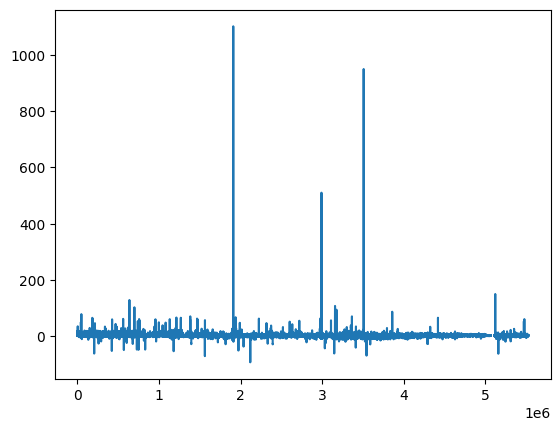

In [48]:
plt.plot(added_beta_df['beta'])
plt.show()

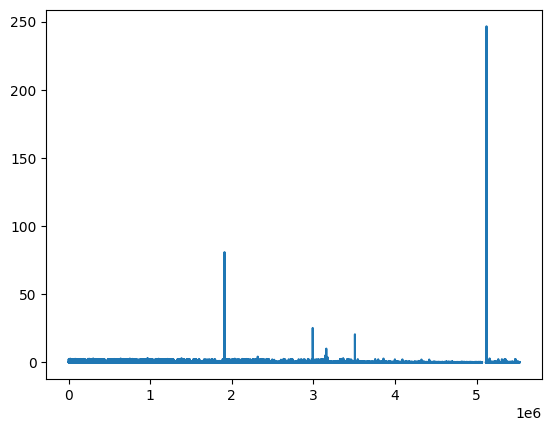

In [ ]:
plt.plot(added_beta_df['volatility'])
plt.show()

In [44]:
added_beta_df['beta'].describe()

count    3.364514e+06
mean     6.216871e-01
std      2.420805e+00
min     -9.459266e+01
25%      1.513617e-02
50%      4.661603e-01
75%      9.984949e-01
max      1.103083e+03
Name: beta, dtype: float64

In [50]:
added_beta_df['volatility'].describe()

count    3.447260e+06
mean     5.164207e-02
std      5.570264e-01
min      0.000000e+00
25%      2.300506e-02
50%      3.768889e-02
75%      5.685165e-02
max      2.464722e+02
Name: volatility, dtype: float64

In [45]:
added_beta_df

,nikkei,week_id,open,weekly_high,weekly_low,close,期中平均株式数累計,１株当たり配当金,時価総額,beta,return,volatility,Rm
0,N0000001,0,142.0,142.0,137.0,139.0,112873941.0,3.0,1.568948e+10,NaN,NaN,NaN,0.000000
1,N0000001,1,131.0,133.0,131.0,131.0,112873941.0,3.0,1.478649e+10,NaN,-0.057554,NaN,-0.017339
2,N0000001,2,134.0,135.0,131.0,132.0,112873941.0,3.0,1.489936e+10,NaN,0.007634,NaN,0.024867
3,N0000001,3,136.0,136.0,133.0,133.0,112873941.0,3.0,1.501223e+10,NaN,0.007576,NaN,0.017242
4,N0000001,4,140.0,141.0,138.0,141.0,112873941.0,3.0,1.591523e+10,NaN,0.060150,NaN,0.004628
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091607,1194,1472.0,1472.0,1472.0,1472.0,2033850.0,0.0,2.993827e+09,-0.036330,-0.008754,0.015026,0.006560
5524988,N0091607,1195,1490.0,1505.0,1490.0,1500.0,2033850.0,0.0,3.050775e+09,-0.069015,0.019022,0.014565,-0.003329
5524989,N0091607,1196,1522.0,1525.0,1499.0,1507.0,2033850.0,0.0,3.065012e+09,-0.067893,0.004667,0.014556,0.012753
5524990,N0091607,1197,1488.0,1488.0,1488.0,1488.0,2033850.0,0.0,3.026369e+09,-0.070607,-0.012608,0.013118,-0.014688


In [51]:
added_beta_df.drop(
    columns=[
        '期中平均株式数累計', '１株当たり配当金', '時価総額', 'Rm',
        'open', 'weekly_high', 'weekly_low', 'close', 'return'
    ], 
    inplace=True
)

In [52]:
added_beta_df

,nikkei,week_id,beta,volatility
0,N0000001,0,NaN,NaN
1,N0000001,1,NaN,NaN
2,N0000001,2,NaN,NaN
3,N0000001,3,NaN,NaN
4,N0000001,4,NaN,NaN
...,...,...,...,...
5524987,N0091607,1194,-0.036330,0.015026
5524988,N0091607,1195,-0.069015,0.014565
5524989,N0091607,1196,-0.067893,0.014556
5524990,N0091607,1197,-0.070607,0.013118


In [53]:
added_beta_df.to_csv('weekly_beta_volatility.csv', index=False)